# Chapter 8 assets: choosing the architecture

Two claims in Chapter 8 need numbers behind them.

1. **Retrained from scratch on WCCI, the candidate-scoring configuration wins
   outright** against the Screen C/D encoders — and `bus14` rank predicts the
   ordering *within* that family while saying nothing *across* families.
2. **It is also the only configuration that can be transferred at all**, which is
   what the rest of the chapter goes on to exploit.

This notebook emits exactly the assets the chapter cites and nothing else:

| asset | destination |
|---|---|
| `wcci_proxy_test.tex` | `latex/tables/` |
| `wcci_action_head.tex` | `latex/tables/` |
| `wcci_action_head.png` | `latex/figures/` |

Both tables are written as `tabular` bodies for `\input`, so re-running this
notebook updates the chapter.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd()))
import wcci_transfer_data as W

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

data = W.load()
wsc = W.load_wsc(data)
DN_HARD, DN_OVERALL = data.dn_hard, data.dn_overall
N_HARD, N_EASY = data.n_hard, data.n_easy

LATEX_DIR = data.task_dir.parent / "latex"
TABLE_DIR, FIGURE_DIR = LATEX_DIR / "tables", LATEX_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Only the final checkpoints: one row per encoder x cap, all at the full budget.
final = wsc.runs.loc[wsc.runs["checkpoint_kind"] == "final"].copy()
# Which screen each encoder came from, per X_wcci_scratch_arch/README.md.
SCREEN_SOURCE = {
    "bus_e0n0v0": "C, baseline",
    "bus_e1n0v0": "C, best cell",
    "het_ga2b_lb2a": "D, best cell",
    "het_gbi_lbi": "D, baseline",
}
final["screen"] = final["schema"].map(SCREEN_SOURCE)

display(Markdown(
    f"Reference frame: do-nothing **{DN_OVERALL:.2f}%** overall, **{DN_HARD:.2f}%** on the "
    f"{N_HARD} difficult chronics.  \n"
    f"`wsc` screen: **{len(final)}** final checkpoints at "
    f"**{int(final['checkpoint_step'].max()):,}** steps, all artifact-verified."
))

Reference frame: do-nothing **56.00%** overall, **8.34%** on the 24 difficult chronics.  
`wsc` screen: **8** final checkpoints at **14,971,392** steps, all artifact-verified.

## Table 1 — what each screen produced, retrained from scratch on WCCI

Screens A--E each settled one design question on `bus14` and produced a winner.
This table takes all of them to the target grid under one protocol: **$k=64$,
15M steps, random initialisation**, no transferred weights anywhere.

| screen | question settled | configuration carried forward |
|---|---|---|
| A + B | encoder depth and width; pooling | `bus_e0n0v0` |
| C | busbar-graph augmentation | `bus_e1n0v0` (same-substation edges) |
| D | heterogeneous graph, message direction | `het_ga2b_lb2a`, `het_gbi_lbi` |
| E | heterogeneous + line nodes, candidate scoring | 8 cells, evaluated as `sc64c` |

`het_gbi_lbi` has no corrected `bus14` rerun — it is the missing cell of Screen
D's factorial — so its anchor is left empty rather than filled from the
pre-correction screen.

In [2]:
from scipy import stats


def tex_escape(text):
    return str(text).replace("_", r"\_")


def num(value, digits=2, dash="--"):
    return dash if pd.isna(value) else f"{value:,.{digits}f}"


SCREEN_OF = {
    "bus_e0n0v0": "A--B", "bus_e1n0v0": "C",
    "het_ga2b_lb2a": "D", "het_gbi_lbi": "D",
}
mlp = final.loc[final["mk"] == 64].sort_values("hard_pct", ascending=False).copy()
mlp["screen"], mlp["label"] = mlp["schema"].map(SCREEN_OF), mlp["schema"]
scorer = (
    data.runs.loc[(data.runs["route"] == "MAPPO scratch") & (data.runs["gate"] == "ungated")]
    .merge(data.bus14, on="variant", how="left")
    .sort_values("hard_pct", ascending=False)
    .assign(screen="E")
    .rename(columns={"variant": "label"})
)

lines = []
for row in pd.concat([mlp, scorer])[
    ["screen", "label", "bus14_pct", "overall_pct", "hard_pct", "easy_kept", "hard_rescues"]
].itertuples():
    lines.append(
        f"    {row.screen} & \\texttt{{{tex_escape(row.label)}}} & {num(row.bus14_pct)} & "
        f"{num(row.overall_pct)} & {num(row.hard_pct)} & {int(row.easy_kept)} & "
        f"{int(row.hard_rescues)} \\\\"
    )
# Keep the two screens visually separated without a rule.
lines.insert(len(mlp), r"    \addlinespace")
table = rf"""% Generated by analysis/metrics/notebooks/episodic_survival/
% chapter08_architecture_selection.ipynb -- do not edit by hand.
\begin{{tabular}}{{llrrrrr}}
  \toprule
  & & bus14 & \multicolumn{{4}}{{c}}{{WCCI, from scratch at $k=64$}} \\
  \cmidrule(lr){{4-7}}
  Screen & Configuration & (\%) & Overall (\%) & Difficult (\%) & Easy kept & Rescues \\
  \midrule
{chr(10).join(lines)}
  \midrule
  \multicolumn{{2}}{{l}}{{\emph{{do nothing}}}} & -- & {DN_OVERALL:.2f} & {DN_HARD:.2f} & {N_EASY} & 0 \\
  \bottomrule
\end{{tabular}}
"""
(TABLE_DIR / "wcci_proxy_test.tex").write_text(table, encoding="utf-8")
print(table)

rho, p_rho = stats.spearmanr(scorer["bus14_pct"], scorer["hard_pct"])
display(Markdown(f"""
**Screen E against everything else, difficult cohort at $k=64$:**
above the do-nothing floor of {DN_HARD:.2f}\% in
**{int((scorer['hard_pct'] > DN_HARD).sum())} of {len(scorer)}** cells against
**{int((mlp['hard_pct'] > DN_HARD).sum())} of {len(mlp)}**; median
**{scorer['hard_pct'].median():.2f}\%** against **{mlp['hard_pct'].median():.2f}\%**;
best **{scorer['hard_pct'].max():.2f}\%** against **{mlp['hard_pct'].max():.2f}\%**;
**{int(scorer['hard_rescues'].max())}** rescues against **{int(mlp['hard_rescues'].max())}**.

Screens A--D span {mlp['bus14_pct'].min():.2f}--{mlp['bus14_pct'].max():.2f}\% on bus14 and
Screen E spans {scorer['bus14_pct'].min():.2f}--{scorer['bus14_pct'].max():.2f}\% — overlapping
ranges, opposite outcomes on WCCI.

Within Screen E, bus14 rank does order the WCCI result: Spearman
**{rho:+.2f}** (p = {p_rho:.3f}).
"""))
display(pd.concat([mlp, scorer])[["screen", "label", "bus14_pct", "overall_pct",
                                  "hard_pct", "easy_kept", "hard_rescues"]])

% Generated by analysis/metrics/notebooks/episodic_survival/
% chapter08_architecture_selection.ipynb -- do not edit by hand.
\begin{tabular}{llrrrrr}
  \toprule
  & & bus14 & \multicolumn{4}{c}{WCCI, from scratch at $k=64$} \\
  \cmidrule(lr){4-7}
  Screen & Configuration & (\%) & Overall (\%) & Difficult (\%) & Easy kept & Rescues \\
  \midrule
    D & \texttt{het\_gbi\_lbi} & -- & 44.95 & 6.80 & 15 & 0 \\
    C & \texttt{bus\_e1n0v0} & 97.19 & 39.63 & 5.15 & 9 & 0 \\
    D & \texttt{het\_ga2b\_lb2a} & 99.12 & 39.54 & 4.59 & 10 & 0 \\
    A--B & \texttt{bus\_e0n0v0} & 95.45 & 29.47 & 4.50 & 4 & 0 \\
    \addlinespace
    E & \texttt{NLS\_tmean\_f0\_a0h0} & 100.00 & 46.10 & 18.46 & 13 & 2 \\
    E & \texttt{NLS\_mean\_f0\_a0h1} & 99.66 & 53.09 & 13.84 & 19 & 0 \\
    E & \texttt{NLS\_tmean\_f1\_a0h0} & 99.37 & 39.62 & 11.93 & 10 & 0 \\
    E & \texttt{NLS\_mean\_f1\_a0h0} & 99.94 & 44.03 & 10.34 & 11 & 0 \\
    E & \texttt{NLS\_tmean\_f0\_a0h1} & 96.55 & 51.18 & 8.89 & 20 & 0 \\
    E

<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
/var/folders/c9/0w0hq35n74x1wlfsgz58kq0c0000gn/T/ipykernel_26104/1752148534.py:70: SyntaxWarning: invalid escape sequence '\%'
  """))
/var/folders/c9/0w0hq35n74x1wlfsgz58kq0c0000gn/T/ipykernel_26104/1752148534.py:70: SyntaxWarning: invalid escape sequence '\%'
  """))
/var/folders/c9/


**Screen E against everything else, difficult cohort at $k=64$:**
above the do-nothing floor of 8.34\% in
**5 of 8** cells against
**0 of 4**; median
**9.61\%** against **4.87\%**;
best **18.46\%** against **6.80\%**;
**2** rescues against **0**.

Screens A--D span 95.45--99.12\% on bus14 and
Screen E spans 93.40--100.00\% — overlapping
ranges, opposite outcomes on WCCI.

Within Screen E, bus14 rank does order the WCCI result: Spearman
**+0.74** (p = 0.037).


,screen,label,bus14_pct,overall_pct,hard_pct,easy_kept,hard_rescues
15,D,het_gbi_lbi,NaN,44.95,6.80,15.00,0.00
11,C,bus_e1n0v0,97.19,39.63,5.15,9.00,0.00
13,D,het_ga2b_lb2a,99.12,39.54,4.59,10.00,0.00
9,A--B,bus_e0n0v0,95.45,29.47,4.50,4.00,0.00
4,E,NLS_tmean_f0_a0h0,100.00,46.10,18.46,13.00,2.00
1,E,NLS_mean_f0_a0h1,99.66,53.09,13.84,19.00,0.00
6,E,NLS_tmean_f1_a0h0,99.37,39.62,11.93,10.00,0.00
2,E,NLS_mean_f1_a0h0,99.94,44.03,10.34,11.00,0.00
5,E,NLS_tmean_f0_a0h1,96.55,51.18,8.89,20.00,0.00
7,E,NLS_tmean_f1_a0h1,93.40,52.14,7.68,19.00,0.00


## Table 2 and the figure — the structural criterion

The comparison that carries the section. Four arms on the same 50 chronics, the
same difficult/easy split and the same reduced action space; they differ in the
actor configuration and in where the weights started.

The matched pair is the middle two rows: **both trained from scratch on WCCI, both
for 15M steps, both at $k=64$**. They differ in the actor configuration only —
which, because `common/action_metadata.py` will not pair candidate pooling with
the busbar schema, means the graph schema and the action head move together and
cannot be separated by this design. The table records both columns so the
confound is visible rather than implied.

In [3]:
cas = data.runs.loc[data.runs["hard_pct"].notna()]
mk64_scratch_cas = cas.loc[(cas["route"] == "MAPPO scratch") & (cas["mk"] == 64)
                           & (cas["gate"] == "ungated")]
mk64_scratch_wsc = final.loc[final["mk"] == 64]
mk64_ft = cas.loc[(cas["route"] == "MAPPO fine-tune (conservative)") & (cas["mk"] == 64)
                  & (cas["gate"] == "ungated")]
mk64_zs = cas.loc[(cas["route"] == "bus14 zero-shot") & (cas["mk"] == 64)
                  & (cas["gate"] == "ungated") & cas["variant"].str.startswith("NLS")]

# Column text is kept short: the table has to fit \textwidth at \small.
ARMS = [
    ("Candidate scorer, fine-tuned", "line-node", "candidate",
     "bus14 + 5M", mk64_ft, "#F58518"),
    ("Candidate scorer, from scratch", "line-node", "candidate",
     "random, 15M", mk64_scratch_cas, "#54A24B"),
    ("MLP head, from scratch", "busbar", "MLP",
     "random, 15M", mk64_scratch_wsc, "#B279A2"),
    ("Candidate scorer, zero-shot", "line-node", "candidate",
     "bus14 only", mk64_zs, "#4C78A8"),
]

rows = []
for label, graph, head, init, frame, _ in ARMS:
    rows.append({
        "arm": label, "graph": graph, "head": head, "initialisation": init,
        "n": len(frame), "above_floor": int((frame["hard_pct"] > DN_HARD).sum()),
        "median_hard": frame["hard_pct"].median(), "best_hard": frame["hard_pct"].max(),
        "rescues": int(frame["hard_rescues"].max()),
    })
summary = pd.DataFrame(rows)

lines = []
for r in summary.itertuples():
    lines.append(
        f"    {r.arm} & {r.graph} & {tex_escape(r.head)} & {r.initialisation} & {r.n} & "
        f"{r.above_floor}/{r.n} & {r.median_hard:.2f} & {r.best_hard:.2f} & {r.rescues} \\\\"
    )
table = rf"""% Generated by analysis/metrics/notebooks/episodic_survival/
% chapter08_architecture_selection.ipynb -- do not edit by hand.
\begin{{tabular}}{{llllrrrrr}}
  \toprule
  Actor & Graph & Head & Init. & $n$ & $>$\,floor & Median & Best & Resc. \\
  \midrule
{chr(10).join(lines)}
  \midrule
  \emph{{do nothing}} & -- & -- & -- & -- & -- & \multicolumn{{2}}{{c}}{{{DN_HARD:.2f}}} & 0 \\
  \bottomrule
\end{{tabular}}
"""
(TABLE_DIR / "wcci_action_head.tex").write_text(table, encoding="utf-8")
print(table)
display(summary)

% Generated by analysis/metrics/notebooks/episodic_survival/
% chapter08_architecture_selection.ipynb -- do not edit by hand.
\begin{tabular}{llllrrrrr}
  \toprule
  Actor & Graph & Head & Init. & $n$ & $>$\,floor & Median & Best & Resc. \\
  \midrule
    Candidate scorer, fine-tuned & line-node & candidate & bus14 + 5M & 8 & 8/8 & 18.09 & 22.14 & 4 \\
    Candidate scorer, from scratch & line-node & candidate & random, 15M & 8 & 5/8 & 9.61 & 18.46 & 2 \\
    MLP head, from scratch & busbar & MLP & random, 15M & 4 & 0/4 & 4.87 & 6.80 & 0 \\
    Candidate scorer, zero-shot & line-node & candidate & bus14 only & 8 & 3/8 & 5.66 & 17.35 & 1 \\
  \midrule
  \emph{do nothing} & -- & -- & -- & -- & -- & \multicolumn{2}{c}{8.34} & 0 \\
  \bottomrule
\end{tabular}



,arm,graph,head,initialisation,n,above_floor,median_hard,best_hard,rescues
0,"Candidate scorer, fine-tuned",line-node,candidate,bus14 + 5M,8,8,18.09,22.14,4
1,"Candidate scorer, from scratch",line-node,candidate,"random, 15M",8,5,9.61,18.46,2
2,"MLP head, from scratch",busbar,MLP,"random, 15M",4,0,4.87,6.80,0
3,"Candidate scorer, zero-shot",line-node,candidate,bus14 only,8,3,5.66,17.35,1


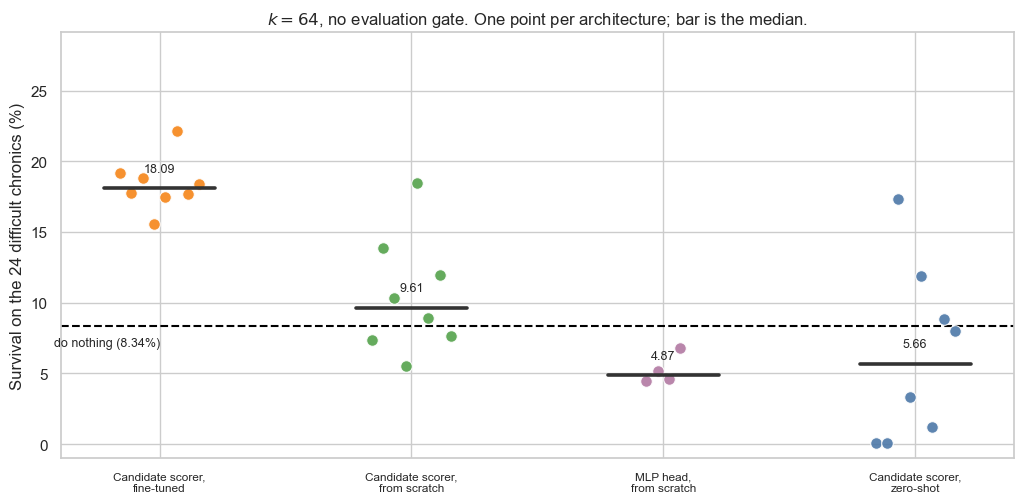

figure -> /Users/corentinplumet/Documents/RL_Marl2grid/latex/figures/wcci_action_head.png
tables -> /Users/corentinplumet/Documents/RL_Marl2grid/latex/tables


In [4]:
fig, ax = plt.subplots(figsize=(10.4, 5.2))
for i, (label, graph, head, init, frame, colour) in enumerate(ARMS):
    values = frame["hard_pct"].to_numpy()
    jitter = (np.arange(len(values)) - (len(values) - 1) / 2) * 0.045
    ax.scatter(np.full(len(values), i) + jitter, values, s=70, color=colour,
               edgecolor="white", linewidth=0.8, zorder=3, alpha=0.9)
    ax.plot([i - 0.22, i + 0.22], [np.median(values)] * 2, color="#333333",
            linewidth=2.6, zorder=4)
    ax.annotate(f"{np.median(values):.2f}", (i, np.median(values)), xytext=(0, 12),
                textcoords="offset points", ha="center", fontsize=9)
ax.axhline(DN_HARD, color="black", linestyle="--", linewidth=1.5)
ax.text(-0.42, DN_HARD - 1.4, f"do nothing ({DN_HARD:.2f}%)", ha="left", fontsize=9)
ax.set_xticks(range(len(ARMS)), [a[0].replace(", ", ",\n") for a in ARMS], fontsize=8.5)
ax.set(ylabel=f"Survival on the {N_HARD} difficult chronics (%)",
       ylim=(-1, max(cas["hard_pct"].max(), 24) * 1.2),
       title=f"$k=64$, no evaluation gate. One point per architecture; bar is the median.")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "wcci_action_head.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"figure -> {FIGURE_DIR / 'wcci_action_head.png'}")
print(f"tables -> {TABLE_DIR}")

## Numbers the prose quotes

Everything the chapter states in words, printed here so it can be checked against
the source rather than transcribed from memory.

In [5]:
best_wsc = wsc.runs["hard_pct"].max()
display(Markdown(f"""
- Best `wsc` run **anywhere**, including best-test checkpoints:
  **{best_wsc:.2f}\\%** — below the do-nothing floor of **{DN_HARD:.2f}\\%**.
- `wsc` above the floor: **{int((wsc.runs['hard_pct'] > DN_HARD).sum())} of {len(wsc.runs)}**
  (difficult), **{int((wsc.runs['overall_pct'] > DN_OVERALL).sum())} of {len(wsc.runs)}** (overall).
- Rescues by any `wsc` run: **{int(wsc.runs['hard_rescues'].max())}** of {N_HARD}.
- Matched from-scratch pair at $k=64$, 15M steps:
  MLP head median **{mk64_scratch_wsc['hard_pct'].median():.2f}\\%**
  ({int((mk64_scratch_wsc['hard_pct'] > DN_HARD).sum())}/{len(mk64_scratch_wsc)} above floor)
  against candidate pool median **{mk64_scratch_cas['hard_pct'].median():.2f}\\%**
  ({int((mk64_scratch_cas['hard_pct'] > DN_HARD).sum())}/{len(mk64_scratch_cas)} above floor).
- Fine-tuned candidate scorer at $k=64$: median **{mk64_ft['hard_pct'].median():.2f}\\%**,
  **{int((mk64_ft['hard_pct'] > DN_HARD).sum())}/{len(mk64_ft)}** above floor,
  up to **{int(mk64_ft['hard_rescues'].max())}** rescues.
- Source-grid correlation across the 16 shared-candidate variants (from the
  transfer digest): **r = -0.01**.
"""))


- Best `wsc` run **anywhere**, including best-test checkpoints:
  **7.21\%** — below the do-nothing floor of **8.34\%**.
- `wsc` above the floor: **0 of 16**
  (difficult), **0 of 16** (overall).
- Rescues by any `wsc` run: **0** of 24.
- Matched from-scratch pair at $k=64$, 15M steps:
  MLP head median **4.87\%**
  (0/4 above floor)
  against candidate pool median **9.61\%**
  (5/8 above floor).
- Fine-tuned candidate scorer at $k=64$: median **18.09\%**,
  **8/8** above floor,
  up to **4** rescues.
- Source-grid correlation across the 16 shared-candidate variants (from the
  transfer digest): **r = -0.01**.
